<a href="https://colab.research.google.com/github/ruforavishnu/Project_Machine_Learning/blob/master/Project24_Reinforcement_Learning_Flappy_Bird_game_played_by_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#section 1

**project 24**

**trying to solve more sophisticated things using RL. trying to make an AI learn to play a video game on its own. we are attempting the most basic game as of now.**

**Flappy Bird**



In [1]:
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install pygame
!pip install pyvirtualdisplay
!pip install imageio
!pip install imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os


import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO

import pygame

from pyvirtualdisplay import Display

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
display = Display(visible=0,  size=(800,600))

display.start()



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
pygame.init()

(4, 1)

**ini flappy bird inte environment ezhuthanam**

In [5]:
!wget https://i.imgur.com/QZx6D8L.png -O bird.png
!wget https://i.imgur.com/2rmKZkR.png -O pipe.png
!wget https://i.imgur.com/fbgD5wR.png -O background.png

--2026-05-25 12:13:28--  https://i.imgur.com/QZx6D8L.png
Resolving i.imgur.com (i.imgur.com)... 199.232.192.193, 199.232.196.193
Connecting to i.imgur.com (i.imgur.com)|199.232.192.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2026-05-25 12:13:28 ERROR 429: Unknown Error.

--2026-05-25 12:13:28--  https://i.imgur.com/2rmKZkR.png
Resolving i.imgur.com (i.imgur.com)... 199.232.192.193, 199.232.196.193
Connecting to i.imgur.com (i.imgur.com)|199.232.192.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2026-05-25 12:13:28 ERROR 429: Unknown Error.

--2026-05-25 12:13:28--  https://i.imgur.com/fbgD5wR.png
Resolving i.imgur.com (i.imgur.com)... 199.232.192.193, 199.232.196.193
Connecting to i.imgur.com (i.imgur.com)|199.232.192.193|:443... connected.
HTTP request sent, awaiting response... 429 Unknown Error
2026-05-25 12:13:28 ERROR 429: Unknown Error.



In [6]:
!rm -f bird.png
!rm -f pipe.png
!rm -f background.png

!wget "https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/yellowbird-midflap.png" -O bird.png

!wget "https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/pipe-green.png" -O pipe.png

!wget "https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/background-day.png" -O background.png

--2026-05-25 12:13:28--  https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/yellowbird-midflap.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 425 [image/png]
Saving to: ‘bird.png’

bird.png            100%[===================>]     425  --.-KB/s    in 0s      

2026-05-25 12:13:28 (10.7 MB/s) - ‘bird.png’ saved [425/425]

--2026-05-25 12:13:28--  https://raw.githubusercontent.com/samuelcust/flappy-bird-assets/master/sprites/pipe-green.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2527 (2.5K) 

In [7]:
import os

print(os.path.getsize("bird.png"))
print(os.path.getsize("pipe.png"))
print(os.path.getsize("background.png"))

425
2527
7026


In [8]:
from IPython.display import Image, display

display(Image(filename='bird.png'))

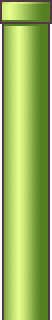

In [9]:
display(Image(filename='pipe.png'))

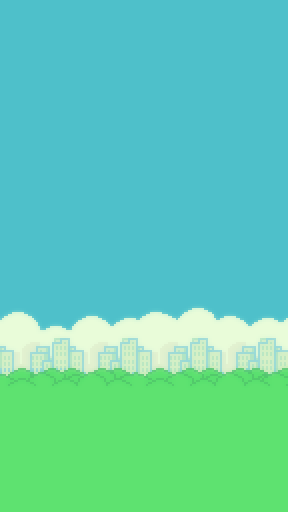

In [10]:
display(Image(filename='background.png'))

In [13]:
import random

In [14]:
class FlappyBirdEnv(gym.Env):

  def __init__(self):

    super(FlappyBirdEnv,  self).__init__()


    self.WIDTH = 400
    self.HEIGHT = 600

    self.screen = pygame.Surface((self.WIDTH,  self.HEIGHT))



    #LOAD sprites
    self.bird_sprite = pygame.image.load('bird.png')
    self.bird_sprite = pygame.transform.scale(self.bird_sprite,   (40,40))


    self.pipe_sprite = pygame.image.load('pipe.png')
    self.pipe_sprite = pygame.transform.scale(self.pipe_sprite,  (60,500))


    self.background = pygame.image.load('background.png')
    self.background = pygame.transform.scale(self.background,  (self.WIDTH, self.HEIGHT))

    # self.bird_x = 100
    # self.bird_y = 300

    ####


    #bird
    self.bird_x = 100
    self.bird_y = 300
    self.bird_velocity = 0



    #pipe
    # self.pipe_x = 400
    # self.pipe_gap = 200
    # self.pipe_top = np.random.randint(100,400)


    self.pipe_width = 60
    self.pipe_gap = 170
    self.pipe_speed = 4
    self.pipe_distance = 250

    self.pipes = []


    #gravity
    self.gravity = 0.5
    self.jump_strength = -8



    #RL spaces
    self.action_space = spaces.Discrete(2)

    self.observation_space = spaces.Box(

                                        low = -np.inf,
                                        high = np.inf,
                                        shape = (5,),
                                        dtype=np.float32
    )



    self.score = 0


    # #load sprites
    # self.bird_sprite = pygame.image.load('bird.png')
    # self.bird_sprite = pygame.transform.scale(self.bird_sprite, (40,40))


    # self.pipe_sprite = pygame.image.load('pipe.png')
    # self.pipe_sprite = pygame.transform.scale(self.pipe_sprite , (60,500))

    # self.background_sprite = pygame.image.load('background.png')
    # self.background_sprite = pygame.transform.scale(self.background_sprite, (self.WIDTH, self.HEIGHT)  )


  def create_pipe(self):

    gap_y = random.randint(150, 450)

    pipe_x = self.WIDTH

    return {
        'x': pipe_x,
        'gap_y' : gap_y
    }



  def reset(self,  seed = None, options=None):

    super().reset(seed=seed)
    self.bird_y = 300
    self.bird_velocity = 0

    self.pipe_x = 400
    self.pipe_top = np.random.randint(100,400)

    self.pipes = []

    for i in range(3):
      pipe = self.create_pipe()
      pipe['x'] +=  i * self.pipe_distance
      self.pipes.append(pipe)




    self.score = 0

    observation = self._get_obs()

    return observation, {}



  def _get_obs(self):


      return np.array([
          self.bird_y ,
          self.bird_velocity,
          self.pipe_x,
          self.pipe_top,
          self.pipe_gap
      ], dtype=np.float32

                      )




  def step(self, action):

      reward = 0.1


      #Jump
      if action == 1:
        self.bird_velocity = self.jump_strength


      #now we have to gravity pull downwards
      self.bird_velocity += self.gravity

      self.bird_y += self.bird_velocity




      # ini moving the pipe
      # self.pipe_x -= 3

      for pipe in self.pipes:
        pipe['x'] -= self.pipe_speed



      for pipe in self.pipes:

        if pipe['x']  < -self.pipe_width:
          pipe['x'] = self.WIDTH
          pipe['gap_y'] = random.randint(150,450)






      #reset pipe
      if self.pipe_x < -50:
        self.pipe_x =400
        self.pipe_top = np.random.randint(100,400)
        self.score += 1
        reward += 10

      #ini collision hapen cheythaal
      done = False


      #rectangle aayitt define cheyyaam. pixel perfect collision cheyaan aayitt ith client inu shipeyaan ulla code onum allalo.
      #so rectangular sprite mathi
      bird_rect = pygame.Rect(
          self.bird_x ,
          int(self.bird_y),
          30,
          30

      )

      top_pipe = pygame.Rect(
          self.pipe_x,
          0,
          50,
          self.pipe_top
      )



      bottom_pipe = pygame.Rect(
          self.pipe_x,
          self.pipe_top + self.pipe_gap,
          50,
          self.HEIGHT
      )



    # oh, ith mathi innathek. baaki naale ezhuthaam.


    # if this works. other scenarios ilum ee RL method use cheyaan pattum. lets wait and see.
    # AI ine kond contra, dd, lionking, alladin okke kalipikaan pattiya. might be fun. but ithokke kond walla profitum generate eyaan patto nnu daivathinu ariyaam.

    # aa nokkaam. lets see.

      if bird_rect.colliderect(top_pipe)  or bird_rect.colliderect(bottom_pipe):
        done = True
        reward = -100




      if self.bird_y < 0 or self.bird_y > self.HEIGHT:
        done = True
        reward = -100


      observation = self._get_obs()


      return observation, reward, done, False, {}


  def render(self):

    self.screen.blit(self.background, (0,0))


    #top pipe
    top_pipe_height = self.pipe_top

    top_pipe = pygame.transform.flip(self.pipe_sprite, False, True)

    top_pipe = pygame.transform.scale(top_pipe, (60, top_pipe_height))

    self.screen.blit(top_pipe,   (self.pipe_x, 0))


# taking a small break. images load cheythu. render function half ezhuthi. ith theerthatt venam. RL model train cheyyaan.

# ath ethra neram edikkuvo entho..have to wait ad see if this works.display


    #bottom pipe
    bottom_pipe_y = self.pipe_top + self.pipe_gap

    bottom_pipe_height = self.HEIGHT - bottom_pipe_y


    bottom_pipe = pygame.transform.scale( self.pipe_sprite,   (60,bottom_pipe_height))


    self.screen.blit(bottom_pipe,   (self.pipe_x, bottom_pipe_y))


    #bird
    self.screen.blit( self.bird_sprite,
                     (
                      int(self.bird_x)  - 20,
                      int(self.bird_y) - 20
                     )

                      )

    return pygame.surfarray.array3d(self.screen)








ini test cheytho nokkatte

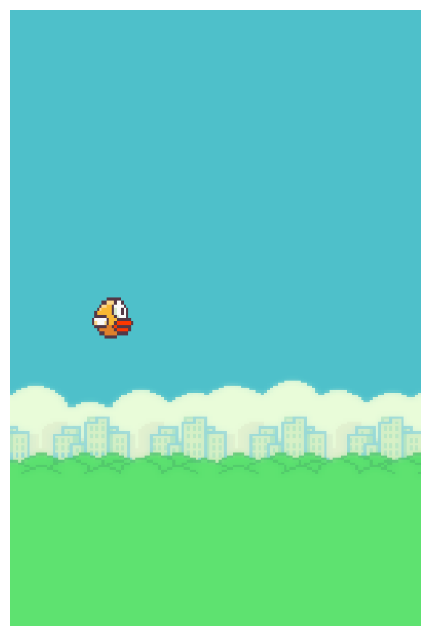

In [15]:

env = FlappyBirdEnv()

obs, _ = env.reset()

frame = env.render()


plt.figure( figsize=(6,8) )
plt.imshow(np.transpose(frame,  (1,0,2) ))
plt.axis('off')
plt.show()

In [ ]:
env = FlappyBirdEnv()

#this sectino of code is the brain of our flappy bird. looks like oe small snetence. but its not. the neural nets behind is huge !
model = PPO("MlpPolicy",  env,  verbose=1)



**ini train cheyikkaam**

In [ ]:
model.learn(total_timesteps=50_000)

model onn save cheyth vachekaaam

In [ ]:
model.save('flappybird_ppo_50k')


In [ ]:
from google.colab import files

files.download('flappybird_ppo_50k.zip')




In [ ]:
!pip install imageio imageio-ffmpeg pillow

In [ ]:
import imageio
import numpy as np

def record_gif(model, env, filename, max_steps=500):

    frames = []

    obs, _ = env.reset()

    done = False
    step = 0

    while not done and step < max_steps:

        action, _states = model.predict(
            obs,
            deterministic=True
        )

        obs, reward, done, truncated, info = env.step(action)

        frame = env.render()

        # Rotate correctly
        frame = np.transpose(frame, (1,0,2))

        # Convert to uint8
        frame = frame.astype(np.uint8)

        frames.append(frame)

        step += 1

    print("Frames captured:", len(frames))

    imageio.mimsave(
        filename,
        frames,
        duration=0.03
    )

    print("GIF saved:", filename)

In [ ]:
record_gif(
    model,
    env,
    "flappybird_fixed.gif"
)

In [ ]:
from IPython.display import HTML
import base64

gif_file = open("flappybird_fixed.gif",'rb').read()

gif_base64 = base64.b64encode(gif_file).decode('utf-8')

HTML(f'''
<img src="data:image/gif;base64,{gif_base64}">
''')

**nice! lets take a break. rl is learning to play flappy bird on its own. 35 frames gif aayitt record cheyaan pati from the rl model. maybe we'll need to train the rl model for more than 50,000 lifetimes to get better perfection**

In [ ]:
model.learn(total_timesteps=3_00_000)



In [ ]:
model.save('flappybird_ppo_3lakh_lifetimes')

In [ ]:
from google.colab import files

files.download('flappybird_ppo_3lakh_lifetimes.zip')


In [ ]:
record_gif(model, env, 'flappybird_ppo_3lakh_lifetimes.gif', max_steps=1000)

In [ ]:
from IPython.display import HTML
import base64

gif_file = open("flappybird_ppo_3lakh_lifetimes.gif",'rb').read()

gif_base64 = base64.b64encode(gif_file).decode('utf-8')

HTML(f'''
<img src="data:image/gif;base64,{gif_base64}">
''')

**shokam! 3 lakh lifetimes vare train cheythu rl model ine. ennitta!**


**daivame ith nalla pani und...naale cheyaam. ith mathi ipo**

#section 2

**We’ll add:**

1. reward for passing pipe
2. reward for staying near gap center
3. smoother motion reward
4. anti-spam flap penalty **bold text**

**that should make our  RL model more  intelligent.**